# Elecciones presidenciales de EE. UU.: informe reproducible

Este notebook muestra paso a paso cómo se construyó el panel estatal de **2000–2024**, qué se analizó y qué resultados se obtuvieron. Cada sección alterna explicación y código ejecutable. Las salidas incluidas provienen de una ejecución completa.

**Pregunta:** ¿el historial electoral y la demografía ayudan a anticipar el partido ganador de un estado?

El voto popular nacional no equivale al Colegio Electoral. Este trabajo evalúa ganadores estatales; **no presenta una predicción de 2028**.

## Cómo usarlo

Abrir en VS Code/Jupyter, seleccionar el entorno Python del proyecto y elegir **Ejecutar todo**. Las dependencias están en `requirements-notebook.txt`. Los archivos fuente ya están incluidos: la ejecución por defecto es **sin red y sin clave de Census**. No introducir claves en celdas ni en sus salidas.

Se reutilizan las funciones de `build_dataset.py` y `analyze.py` para que el notebook y los scripts compartan la lógica. El notebook no reemplaza los datos originales ni los informes existentes.

## Qué queremos explicar con este trabajo

| Fuente | Qué aporta | Qué limpiamos/transformamos | Uso efectivo en esta versión |
|---|---|---|---|
| MIT/MEDSL | Resultado real y comportamiento electoral anterior | Agregación partidaria, totales, porcentajes y rezagos por estado | Etiqueta y predictores históricos |
| Census ACS | Contexto demográfico del estado | Tablas antiguas, universos, porcentajes y códigos negativos especiales | Exploración; educación, edad y pobreza en el modelo ampliado |
| FRED | Contexto económico nacional | Frecuencia temporal, promedio previo y variaciones interanuales | Dataset descriptivo; fuera de los modelos |
| FiveThirtyEight | Intención de voto preelectoral | Fecha de corte, candidatura, última estimación y cobertura | Integración exploratoria; fuera del entrenamiento retrospectivo |

**Curar** significa verificar procedencia, significado, consistencia, cobertura y oportunidad temporal. Los faltantes permanecen documentados; no se los convierte en cero ni se ocultan resultados desfavorables.

Las relaciones de unión (mismo estado y elección) permiten construir el panel. Las correlaciones estadísticas se estudian después y no prueban causalidad. Cada sección muestra qué entra, qué transformación se aplica y qué resultado deja.

## 1. Preparar el entorno

Localizamos el repositorio, importamos las herramientas y configuramos una caché local para gráficos. La ruta se resuelve tanto al abrir desde la raíz como desde `notebooks/`.

In [1]:
from pathlib import Path
import os
import sys
import json
import hashlib
import subprocess

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "build_dataset.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Abrir el notebook dentro del repositorio Ciencia-datos-.")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / ".cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import build_dataset as builder
from analyze import backtest, census_comparison, FEATURES, CENSUS_FEATURES

%matplotlib inline
pd.set_option("display.max_columns", 15)
plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 120})
OFFLINE = True
print("Python:", sys.version.split()[0])
print("Modo sin red:", OFFLINE)

Python: 3.12.14
Modo sin red: True


## 2. Revisar los archivos fuente

Utilizamos resultados MIT/MEDSL, encuestas históricas de FiveThirtyEight, series FRED y Census ACS. El manifiesto registra las fuentes y huellas SHA-256; verificamos que los archivos conservan exactamente los bytes registrados.

Los resultados históricos provienen de un mirror de Plotly; 2024 del repositorio MEDSL. Los CSV de FRED son públicos. Las encuestas están comprimidas para reducir el tamaño del repositorio.

In [2]:
manifest = json.loads((ROOT / "data/raw/manifest.json").read_text())
for entry in manifest:
    path = ROOT / "data/raw" / entry["file"]
    assert hashlib.sha256(path.read_bytes()).hexdigest() == entry["sha256"], path.name
display(pd.DataFrame(manifest)[["file", "bytes", "url"]])
print(f"{len(manifest)} archivos fuente verificados.")

,file,bytes,url
0,1976-2020-president.csv,514153,https://raw.githubusercontent.com/plotly/Figur...
1,2024-president-state.csv,75635,https://raw.githubusercontent.com/MEDSL/2024-e...
2,census_2006_acs1.json,33463,https://api.census.gov/data/2006/acs/acs1
3,census_2010_acs5.json,33749,https://api.census.gov/data/2010/acs/acs5
4,census_2014_acs5.json,9086,https://api.census.gov/data/2014/acs/acs5
5,census_2018_acs5.json,9103,https://api.census.gov/data/2018/acs/acs5
6,census_2022_acs5.json,9117,https://api.census.gov/data/2022/acs/acs5
7,fred_CPIAUCSL.csv,17744,https://fred.stlouisfed.org/graph/fredgraph.cs...
8,fred_GDPC1.csv,6527,https://fred.stlouisfed.org/graph/fredgraph.cs...
9,fred_UNRATE.csv,14196,https://fred.stlouisfed.org/graph/fredgraph.cs...


11 archivos fuente verificados.


## 3. Cargar y transformar los resultados electorales

Los archivos originales contienen filas por candidatura/línea partidaria. Se agregan votos por estado y elección, evitando contar TOTAL junto con modos desagregados. Los porcentajes usan el total oficial, incluyendo terceros candidatos.

El margen se define como `dem_pct − rep_pct`: positivo indica ganador demócrata, negativo republicano. Procesar también 1996 permite obtener el historial previo de 2000.

In [3]:
historical_raw = builder.cached_csv("1976-2020-president.csv", offline=OFFLINE)
results_2024_raw = builder.cached_csv("2024-president-state.csv", offline=OFFLINE)
print("Filas históricas originales:", len(historical_raw))
print("Filas originales 2024:", len(results_2024_raw))
display(results_2024_raw.head(5))

historical = builder.aggregate_returns(historical_raw)
results_2024 = builder.aggregate_returns(results_2024_raw)
all_elections = pd.concat([historical, results_2024], ignore_index=True)
assert not all_elections.duplicated(["year", "state_po"]).any()
elections = builder.previous_features(all_elections)
elections = elections[elections.year.isin(builder.YEARS)].reset_index(drop=True)
display(elections.assign(state=elections.state.str.title())[["year", "state", "dem_pct", "rep_pct", "margin", "winner", "previous_margin"]].head(10))

Filas históricas originales: 4287
Filas originales 2024: 535


,year,state,state_po,state_fips,state_ic,office,candidate,...,mode,votes,totalvotes,stage,special,unofficial,version
0,2024,ALASKA,AK,2,81.0,US PRESIDENT,"HARRIS, KAMALA D.",...,TOTAL,140026,338177,GEN,False,False,2025-11-20
1,2024,ALASKA,AK,2,81.0,US PRESIDENT,"KENNEDY, ROBERT F. JR",...,TOTAL,5670,338177,GEN,False,False,2025-11-20
2,2024,ALASKA,AK,2,81.0,US PRESIDENT,"OLIVER, CHASE",...,TOTAL,3040,338177,GEN,False,False,2025-11-20
3,2024,ALASKA,AK,2,81.0,US PRESIDENT,"SONSKI, PETER",...,TOTAL,702,338177,GEN,False,False,2025-11-20
4,2024,ALASKA,AK,2,81.0,US PRESIDENT,"STEIN, JILL",...,TOTAL,2342,338177,GEN,False,False,2025-11-20


,year,state,dem_pct,rep_pct,margin,winner,previous_margin
0,2000,Alaska,27.666340,58.620955,-30.954615,REPUBLICAN,-17.534145
1,2004,Alaska,35.516862,61.065330,-25.548468,REPUBLICAN,-30.954615
2,2008,Alaska,37.889374,59.424520,-21.535146,REPUBLICAN,-25.548468
3,2012,Alaska,40.812659,54.801577,-13.988918,REPUBLICAN,-21.535146
4,2016,Alaska,36.550871,51.281512,-14.730641,REPUBLICAN,-13.988918
5,2020,Alaska,42.771952,52.833143,-10.061191,REPUBLICAN,-14.730641
6,2024,Alaska,41.406128,54.544809,-13.138682,REPUBLICAN,-10.061191
7,2000,Alabama,41.566503,56.483755,-14.917252,REPUBLICAN,-6.965756
8,2004,Alabama,36.844402,62.460690,-25.616287,REPUBLICAN,-14.917252
9,2008,Alabama,38.740434,60.316913,-21.576479,REPUBLICAN,-25.616287


## 4. Preparar las encuestas

Se toma la última estimación de cada candidatura hasta el **31 de octubre**, con antigüedad máxima de 30 días. No se promedian indiscriminadamente todas las encuestas del año.

El archivo disponible cubre 2000–2016 y fue reconstruido/publicado retrospectivamente. Se conserva para exploración, **no se utiliza como predictor en el backtest**. Los faltantes de 2020/2024 no se inventan ni se reemplazan por cero.

In [4]:
state_names = elections[["state", "state_po"]].drop_duplicates().set_index("state").state_po.to_dict()
polls = builder.polls(state_names, offline=OFFLINE)
display(polls.assign(state=polls.state_po.map(elections.drop_duplicates("state_po").set_index("state_po").state.str.title())).drop(columns="state_po").head(8))
display(polls.groupby("year")[["poll_dem", "poll_rep", "poll_margin"]].count())

,poll_dem,poll_rep,year,poll_margin,state
0,25.651124,47.227266,2000,-21.576142,Alaska
1,36.612477,52.792176,2000,-16.179699,Alabama
2,43.849492,45.524948,2000,-1.675456,Arkansas
3,39.764712,49.260386,2000,-9.495674,Arizona
4,46.165362,40.061522,2000,6.103840,California
5,37.263139,47.832048,2000,-10.568909,Colorado
6,46.339066,36.946178,2000,9.392888,Connecticut
7,72.644118,14.148045,2000,58.496073,District Of Columbia


,poll_dem,poll_rep,poll_margin
year,,,
2000,51,51,51
2004,49,49,49
2008,50,50,50
2012,47,47,47
2016,51,51,51


## 5. Incorporar Census

Para 2008 utilizamos ACS 1-year de 2006; desde 2012, ACS 5-year de dos años anteriores a la elección. Se excluyen años posteriores. ACS 5-year representa un período de cinco años, no una observación puntual.

Las tablas antiguas de 2006/2010 requieren códigos distintos para educación y empleo. El script suma categorías equivalentes. Educación usa la población de 25 años o más; pobreza y desempleo usan sus propios universos. Raza y origen hispano se solapan.

Las respuestas JSON están guardadas **sin la clave de API**. Census no se incorpora para 2000/2004 en este pipeline. Los códigos negativos especiales se convierten en faltantes.

In [5]:
census_frames = [builder.census(year, offline=OFFLINE) for year in builder.YEARS if year >= 2008]
census = pd.concat(census_frames, ignore_index=True)
display(census[["year", "census_reference_year", "census_product"]].drop_duplicates().sort_values("year"))
display(census.assign(state=census.state_fips.map(elections.drop_duplicates("state_fips").set_index("state_fips").state.str.title()))[["year", "state", "population", "college_pct", "median_income", "poverty_pct", "unemployment_pct"]].head())

,year,census_reference_year,census_product
0,2008,2006,acs1
52,2012,2010,acs5
104,2016,2014,acs5
156,2020,2018,acs5
208,2024,2022,acs5


,year,state,population,college_pct,median_income,poverty_pct,unemployment_pct
0,2008,Alabama,4599030,21.066547,38783,16.555976,6.896671
1,2008,Alaska,670053,26.851045,59393,10.877197,9.438782
2,2008,Arizona,6166318,25.464040,47265,14.166024,4.880160
3,2008,Arkansas,2810872,18.222186,36599,17.264180,6.963967
4,2008,California,36457549,28.989960,56645,13.146722,6.614179


## 6. Preparar la economía

FRED aporta desempleo (`UNRATE`), precios (`CPIAUCSL`) y PIB real (`GDPC1`). Se calculan promedios del año **anterior** a la elección y variaciones interanuales de esos promedios.

Las series tienen revisiones históricas: este recorte evita incluir meses posteriores, pero no reconstruye los valores publicados en tiempo real. Los indicadores nacionales se repiten para todos los estados del mismo año. No se utilizan en los modelos de esta versión.

In [6]:
economy = builder.economy(offline=OFFLINE)
display(economy[["year", "economy_reference_year", "unemployment", "inflation_pct", "gdp_growth_pct"]])
assert economy.economy_reference_year.eq(economy.year - 1).all()

,year,economy_reference_year,unemployment,inflation_pct,gdp_growth_pct
observation_date,,,,,
1999,2000,1999,4.216667,2.193139,4.788427
2003,2004,2003,5.991667,2.297999,2.795613
2007,2008,2007,4.616667,2.870550,2.003864
2011,2012,2011,8.933333,3.139652,1.564407
2015,2016,2015,5.275000,0.121137,2.945549
2019,2020,2019,3.675000,1.813259,2.583832
2023,2024,2023,3.625000,4.126963,2.918555


## 7. Unificar el panel y validar

Unimos encuestas por año y abreviatura estatal; Census por año y FIPS; economía por año. `validate` en los joins verifica sus cardinalidades. El panel debe mantener **357 filas únicas**: 7 elecciones × 51 jurisdicciones.

Los resultados actuales (`margin`, `winner`, `target_democrat`) son etiquetas o datos descriptivos, nunca entradas del modelo de esa misma elección.

**Ejemplo de lectura:** Pennsylvania–2024 se relaciona con su historial de 2020, ACS de referencia 2022 y economía nacional de 2023. Son relaciones de identidad y tiempo. Después se analiza si sus características ayudan a estimar el ganador. Las columnas observadas de 2024 permanecen como etiquetas, nunca como entradas para predecir 2024.

In [7]:
master = elections.merge(polls, on=["year", "state_po"], how="left", validate="one_to_one")
master = master.merge(census, on=["year", "state_fips"], how="left", validate="one_to_one")
master = master.merge(economy, on="year", how="left", validate="many_to_one")
master["target_democrat"] = master.winner.map({"DEMOCRAT": 1, "REPUBLICAN": 0}).astype("Int64")
master["state_year"] = master.state_po + "_" + master.year.astype(str)
builder.validate(master)
print(f"Panel: {master.shape[0]} filas y {master.shape[1]} columnas")
display(master.assign(state=master.state.str.title()).drop(columns=["state_po", "state_fips", "state_year"]).head())

# Verificar que los pasos reconstruyen el dataset ya entregado.
saved = pd.read_csv(ROOT / "data/processed/elections_master.csv", dtype={"state_fips": str})
cols = sorted(master.columns)
pd.testing.assert_frame_equal(
    master[cols].sort_values(["state_po", "year"]).reset_index(drop=True),
    saved[cols].sort_values(["state_po", "year"]).reset_index(drop=True),
    check_dtype=False, rtol=1e-9, atol=1e-9,
)
print("El panel reconstruido coincide con elections_master.csv.")

Panel: 357 filas y 37 columnas


,year,state,total_votes,dem_votes,rep_votes,other_votes,dem_pct,...,hispanic_pct,poverty_pct,economy_reference_year,unemployment,inflation_pct,gdp_growth_pct,target_democrat
0,2000,Alaska,285560,79004,167398,39158,27.666340,...,NaN,NaN,1999,4.216667,2.193139,4.788427,0
1,2004,Alaska,312598,111025,190889,10684,35.516862,...,NaN,NaN,2003,5.991667,2.297999,2.795613,0
2,2008,Alaska,326197,123594,193841,8762,37.889374,...,NaN,10.877197,2007,4.616667,2.870550,2.003864,0
3,2012,Alaska,300495,122640,164676,13179,40.812659,...,5.554631,9.520585,2011,8.933333,3.139652,1.564407,0
4,2016,Alaska,318608,116454,163387,38767,36.550871,...,6.212687,10.104396,2015,5.275000,0.121137,2.945549,0


El panel reconstruido coincide con elections_master.csv.


## 8. Revisar cobertura y faltantes

La descarga de las fuentes implementadas terminó, pero eso no implica ausencia de faltantes. Census tiene 102 filas sin demografía (2000/2004); las encuestas presentan 109 filas faltantes. `hispanic_pct` también tiene faltantes adicionales en 2008 por códigos especiales de origen.

Los faltantes permanecen vacíos. Ningún modelo usa `hispanic_pct` en esta versión. Deben investigarse antes de incorporarla a un análisis o modelo; no corresponde convertirlos en cero.

In [8]:
missing = master.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = missing.missing_count / len(master) * 100
display(missing[missing.missing_count > 0].sort_values("missing_count", ascending=False))
display(master.groupby("year")[["population", "college_pct", "hispanic_pct", "poll_margin"]].count())
assert master.query("year >= 2008").population.notna().all()
assert master.query("year < 2008").population.isna().all()

,missing_count,missing_pct
hispanic_pct,115,32.212885
poll_dem,109,30.532213
poll_margin,109,30.532213
poll_rep,109,30.532213
census_product,102,28.571429
census_reference_year,102,28.571429
population,102,28.571429
median_age,102,28.571429
college_pct,102,28.571429
median_income,102,28.571429


,population,college_pct,hispanic_pct,poll_margin
year,,,,
2000,0,0,0,51
2004,0,0,0,49
2008,51,51,38,50
2012,51,51,51,47
2016,51,51,51,51
2020,51,51,51,0
2024,51,51,51,0


## 9. Analizar el voto popular nacional

Para obtener un porcentaje nacional sumamos los votos de los estados antes de dividir. Promediar sus porcentajes daría el mismo peso a estados con poblaciones muy distintas. La suma nacional es descriptiva: no determina por sí sola la presidencia.

,dem_pct,rep_pct,margin
year,,,
2000,48.14,47.65,0.49
2004,48.14,50.57,-2.43
2008,52.76,45.36,7.40
2012,50.92,46.98,3.94
2016,48.01,45.83,2.18
2020,51.26,46.82,4.45
2024,48.27,49.74,-1.47


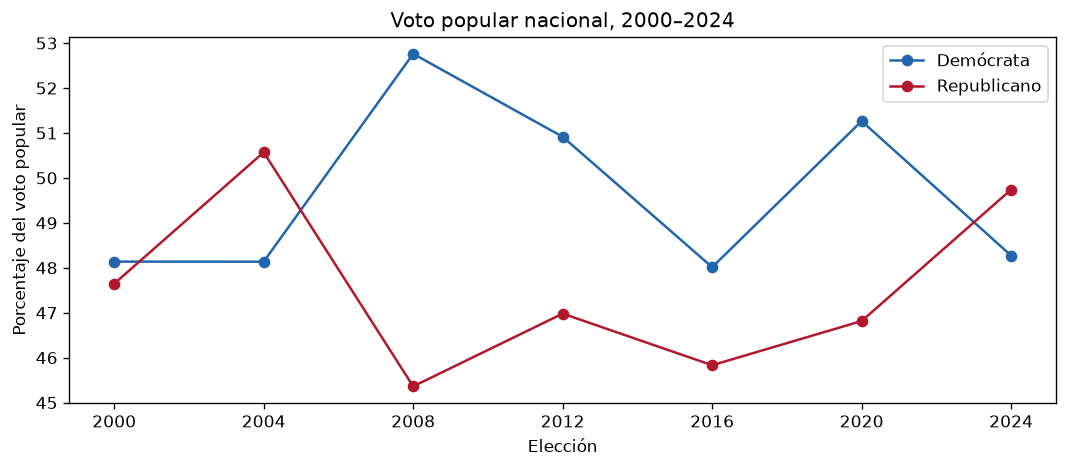

In [9]:
national = master.groupby("year")[["dem_votes", "rep_votes", "other_votes", "total_votes"]].sum()
national["dem_pct"] = national.dem_votes / national.total_votes * 100
national["rep_pct"] = national.rep_votes / national.total_votes * 100
national["margin"] = national.dem_pct - national.rep_pct
display(national[["dem_pct", "rep_pct", "margin"]].round(2))
fig, ax = plt.subplots()
ax.plot(national.index, national.dem_pct, marker="o", color="#2166ac", label="Demócrata")
ax.plot(national.index, national.rep_pct, marker="o", color="#b2182b", label="Republicano")
ax.set(xlabel="Elección", ylabel="Porcentaje del voto popular", title="Voto popular nacional, 2000–2024", xticks=national.index)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** el margen nacional demócrata fue positivo en cinco de las siete elecciones. En 2024 el margen fue republicano por aproximadamente 1,47 puntos porcentuales. Estos resultados se refieren al voto popular, no a una simulación del Colegio Electoral.

## 10. Identificar estados competitivos de 2024

Ordenamos por el valor absoluto del margen. Esta selección usa resultados ya conocidos y sirve para describir la elección. Para evaluar pronósticos en estados competitivos, la selección debería realizarse con información anterior.

,state,dem_pct,rep_pct,margin,winner
342,Wisconsin,48.74,49.60,-0.86,REPUBLICAN
160,Michigan,48.31,49.73,-1.41,REPUBLICAN
272,Pennsylvania,48.66,50.37,-1.71,REPUBLICAN
76,Georgia,48.53,50.72,-2.19,REPUBLICAN
216,New Hampshire,50.36,47.59,2.76,DEMOCRAT
237,Nevada,47.49,50.59,-3.10,REPUBLICAN
195,North Carolina,47.65,50.86,-3.21,REPUBLICAN
167,Minnesota,50.92,46.68,4.24,DEMOCRAT
27,Arizona,46.70,52.23,-5.53,REPUBLICAN
321,Virginia,51.82,46.06,5.77,DEMOCRAT


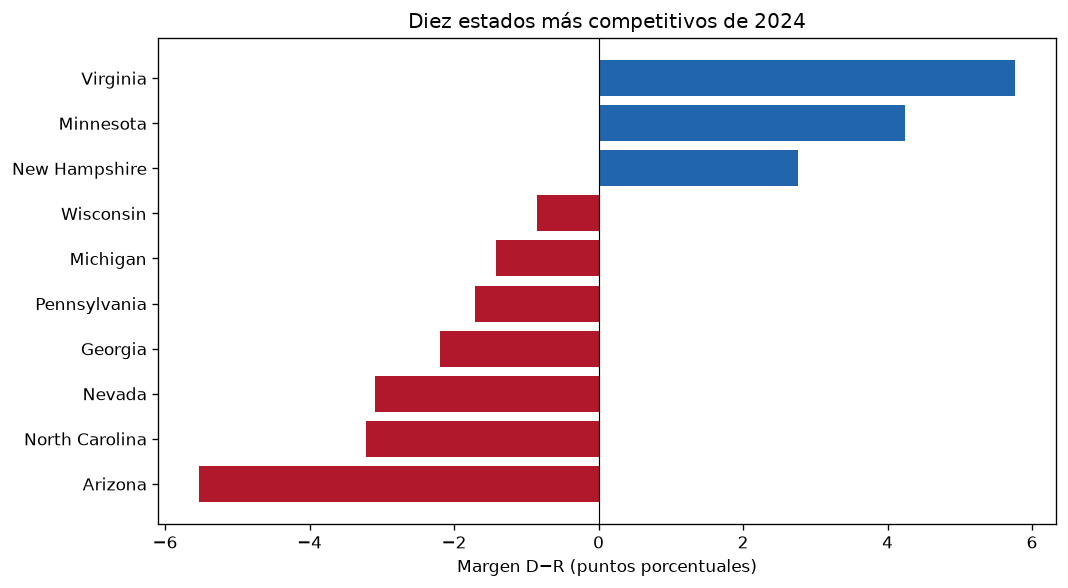

In [10]:
competitive = master.query("year == 2024").assign(abs_margin=lambda x: x.margin.abs()).sort_values("abs_margin").head(10)
display(competitive.assign(state=competitive.state.str.title())[["state", "dem_pct", "rep_pct", "margin", "winner"]].round(2))
plot_data = competitive.sort_values("margin")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.state.str.title(), plot_data.margin, color=np.where(plot_data.margin >= 0, "#2166ac", "#b2182b"))
ax.axvline(0, color="black", linewidth=.7)
ax.set(xlabel="Margen D−R (puntos porcentuales)", title="Diez estados más competitivos de 2024")
plt.tight_layout()
plt.show()

## 11. Explorar la demografía

Calculamos correlaciones dentro de una misma elección para evitar mezclar indiscriminadamente años. En 2024 se relacionan las estimaciones ACS de referencia 2022 con el resultado observado.

Una correlación estatal no prueba causalidad ni describe directamente el voto individual. El ingreso es nominal y debe ajustarse por inflación antes de compararlo entre años. DC puede influir en los resultados y conviene revisar sensibilidad a su inclusión.

,pearson_r
college_pct,0.844
median_income,0.720
median_age,0.139
poverty_pct,-0.295
unemployment_pct,0.369


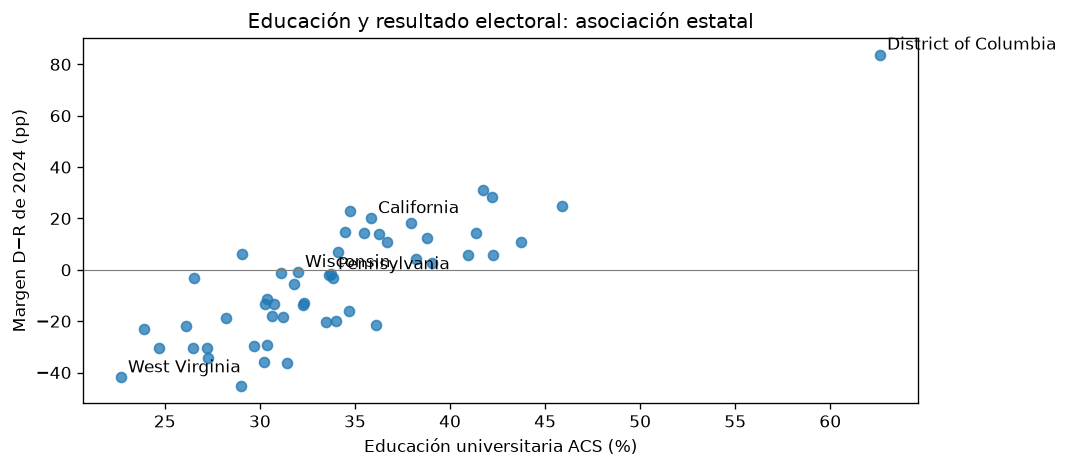

In [11]:
current = master.query("year == 2024")
demographic_cols = ["college_pct", "median_income", "median_age", "poverty_pct", "unemployment_pct"]
correlations = current[demographic_cols + ["margin"]].corr()["margin"].drop("margin")
display(correlations.rename("pearson_r").to_frame().round(3))
fig, ax = plt.subplots()
ax.scatter(current.college_pct, current.margin, alpha=.75)
for state in ["DC", "WI", "PA", "CA", "WV"]:
    row = current[current.state_po == state].iloc[0]
    ax.annotate(row.state.title().replace("District Of Columbia", "District of Columbia"), (row.college_pct, row.margin), xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="gray", linewidth=.7)
ax.set(xlabel="Educación universitaria ACS (%)", ylabel="Margen D−R de 2024 (pp)", title="Educación y resultado electoral: asociación estatal")
plt.tight_layout()
plt.show()

**Interpretación:** educación e ingreso presentan asociaciones positivas fuertes con el margen demócrata de 2024. Esto motiva revisar modelos, pero no garantiza que esas variables mejoren la predicción de otra elección.

## 12. Evaluar el modelo histórico con cortes temporales

La regresión logística usa solo `previous_margin` y `previous_dem_pct`. Para cada elección se entrena con años anteriores; la estandarización se ajusta dentro del entrenamiento. Se compara con repetir el ganador anterior.

Ejemplo: evaluar 2024 implica entrenar con 2000–2020. **No se realiza un split aleatorio de estados**, porque mezclaría elecciones entre entrenamiento y evaluación.

Accuracy mide ganadores acertados; balanced accuracy contempla ambas clases. Brier y log loss miden error de las probabilidades: menor es mejor. Las probabilidades no se consideran calibradas solo por tener buenas métricas.

**Qué significa entrenar:** `fit(X_train, y_train)` aprende las medias/desviaciones para escalar las variables y los coeficientes de una regresión logística regularizada. Con esos coeficientes, `predict_proba(X_test)` transforma las entradas de una nueva fila en una probabilidad de ganador demócrata. El umbral 0,5 convierte esa probabilidad en un partido previsto. No se están prediciendo porcentajes de voto ni nombres de candidatos.

La regresión aprende una puntuación lineal sobre variables estandarizadas y la convierte mediante `p = 1 / (1 + exp(-z))`. Los pesos se estiman a partir de los ejemplos, no se asignan manualmente. `C=1.0` regula la penalización; `max_iter=1000` limita la optimización. Se mantuvieron fijos.

Entradas del modelo: ['previous_margin', 'previous_dem_pct']


,year,train_rows,test_rows,accuracy,balanced_accuracy,baseline_accuracy,brier_score,log_loss
0,2008,102,51,0.784,0.810,0.824,0.151,0.479
1,2012,153,51,0.941,0.938,0.961,0.039,0.147
2,2016,204,51,0.882,0.900,0.882,0.084,0.256
3,2020,255,51,0.824,0.827,0.902,0.097,0.274
4,2024,306,51,0.882,0.903,0.882,0.057,0.177


Modelo histórico: 220/255 aciertos (86.27%)
Repetir ganador previo: 227/255 aciertos (89.02%)


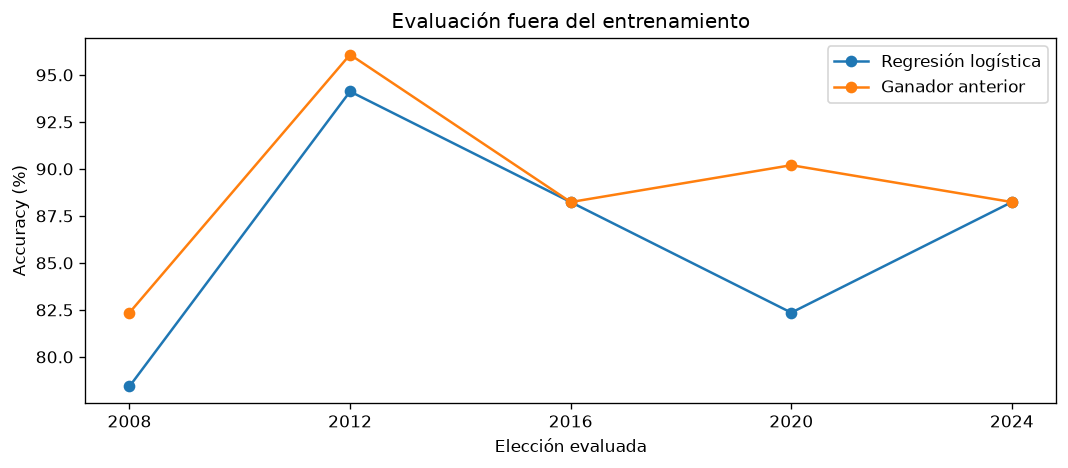

In [12]:
print("Entradas del modelo:", FEATURES)
scores, predictions = backtest(master)
display(scores.round(3))
model_hits = int(predictions.correct.sum())
baseline_hits = int(round((scores.baseline_accuracy * scores.test_rows).sum()))
print(f"Modelo histórico: {model_hits}/{len(predictions)} aciertos ({model_hits / len(predictions):.2%})")
print(f"Repetir ganador previo: {baseline_hits}/{len(predictions)} aciertos ({baseline_hits / len(predictions):.2%})")
fig, ax = plt.subplots()
ax.plot(scores.year, scores.accuracy * 100, marker="o", label="Regresión logística")
ax.plot(scores.year, scores.baseline_accuracy * 100, marker="o", label="Ganador anterior")
ax.set(xlabel="Elección evaluada", ylabel="Accuracy (%)", title="Evaluación fuera del entrenamiento", xticks=scores.year)
ax.legend()
plt.tight_layout()
plt.show()

**Resultado:** el modelo inicial acierta 220 de 255 casos (86,27%); repetir el ganador anterior acierta 227 (89,02%). No se demostró una mejora sobre la regla simple. Acertar estados seguros puede elevar la accuracy sin resolver bien los estados decisivos.

### Abrir el entrenamiento: ejemplo de evaluación de 2024

La siguiente celda muestra las entradas, las etiquetas, el escalado aprendido, los coeficientes y una predicción histórica de Pennsylvania. Solo usa el modelo electoral inicial; la comparación con Census aparece después.

La probabilidad se calcula sin entregar al modelo los resultados de 2024. Luego se muestra el ganador real para evaluarla. Los coeficientes describen este ajuste, no efectos causales.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

train_2024 = master[master.year < 2024]
test_2024 = master[master.year == 2024]
X_train = train_2024[FEATURES]
y_train = train_2024.target_democrat
X_test = test_2024[FEATURES]
assert train_2024.year.max() < test_2024.year.min()
print(f"Entrenamiento: {len(X_train)} filas; evaluación: {len(X_test)} filas")
display(train_2024[["state", "year", *FEATURES, "target_democrat"]].head())

fitted = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
fitted.fit(X_train, y_train)
scaler = fitted.named_steps["standardscaler"]
classifier = fitted.named_steps["logisticregression"]
display(pd.DataFrame({"variable": FEATURES, "media_entrenamiento": scaler.mean_, "desviacion_entrenamiento": scaler.scale_, "coeficiente": classifier.coef_[0]}))
print("Intercepto aprendido:", round(float(classifier.intercept_[0]), 4))

pa = test_2024[test_2024.state_po == "PA"]
p_dem = float(fitted.predict_proba(pa[FEATURES])[0, 1])
example = pd.DataFrame({"estado": ["Pennsylvania"], "eleccion_evaluada": [2024], "p_democrata": [p_dem], "p_republicano": [1-p_dem], "partido_previsto": ["DEMOCRAT" if p_dem >= .5 else "REPUBLICAN"], "ganador_observado": [pa.winner.iloc[0]]})
display(example)
reference_p = predictions.query("year == 2024 and state_po == 'PA'").p_democrat.item()
assert np.isclose(p_dem, reference_p)


Entrenamiento: 306 filas; evaluación: 51 filas


,state,year,previous_margin,previous_dem_pct,target_democrat
0,ALASKA,2000,-17.534145,33.267114,0
1,ALASKA,2004,-30.954615,27.666340,0
2,ALASKA,2008,-25.548468,35.516862,0
3,ALASKA,2012,-21.535146,37.889374,0
4,ALASKA,2016,-13.988918,40.812659,0


,variable,media_entrenamiento,desviacion_entrenamiento,coeficiente
0,previous_margin,-0.346671,21.615890,1.940745
1,previous_dem_pct,47.513688,10.788308,2.458610


Intercepto aprendido: -0.2338


,estado,eleccion_evaluada,p_democrata,p_republicano,partido_previsto,ganador_observado
0,Pennsylvania,2024,0.615496,0.384504,DEMOCRAT,REPUBLICAN


## 13. Comparar modelos con y sin Census

La comparación se realiza sobre **las mismas filas** con ACS disponible desde 2008. Se evalúan 2016, 2020 y 2024 para tener al menos dos elecciones anteriores de entrenamiento.

El modelo ampliado agrega educación universitaria, edad mediana y pobreza. La muestra difiere de la del modelo inicial; por eso la comparación válida es entre los dos modelos de esta sección, no contra resultados de un entrenamiento con más años. Los hiperparámetros permanecen fijos; no se eligen según resultados de 2024.

Variables demográficas adicionales: ['college_pct', 'median_age', 'poverty_pct']


,year,model,train_rows,test_rows,accuracy,brier_score,log_loss,baseline_accuracy
0,2016,historical_same_sample,102,51,0.863,0.106,0.328,0.882
1,2016,historical_plus_census,102,51,0.863,0.091,0.279,0.882
2,2020,historical_same_sample,153,51,0.843,0.072,0.225,0.902
3,2020,historical_plus_census,153,51,0.902,0.071,0.220,0.902
4,2024,historical_same_sample,204,51,0.863,0.075,0.224,0.882
5,2024,historical_plus_census,204,51,0.804,0.124,0.344,0.882


model,historical_plus_census,historical_same_sample
year,,
2016,86.27,86.27
2020,90.20,84.31
2024,80.39,86.27


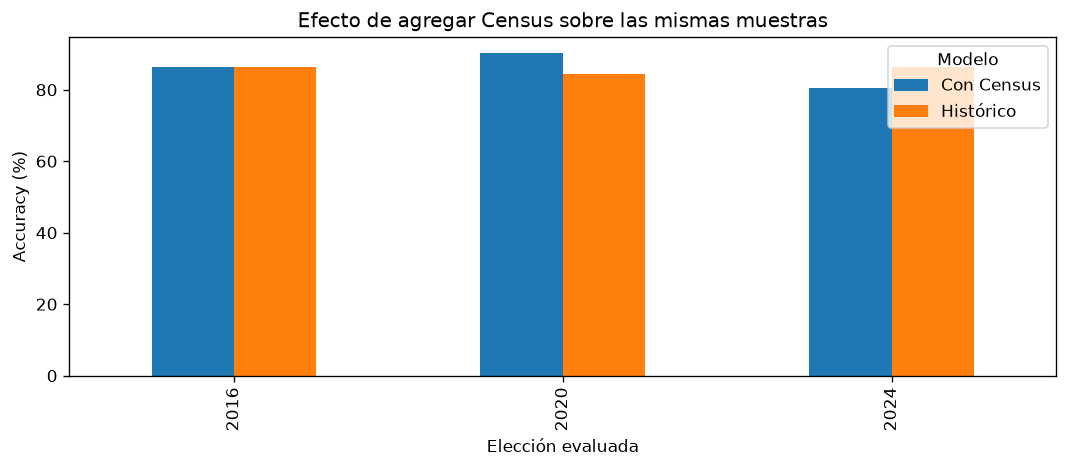

In [14]:
print("Variables demográficas adicionales:", CENSUS_FEATURES)
comparison = census_comparison(master)
assert len(comparison) == 6
assert comparison.groupby("year").train_rows.nunique().eq(1).all()
display(comparison.round(3))
accuracy_table = comparison.pivot(index="year", columns="model", values="accuracy")
display((accuracy_table * 100).round(2))
ax = (accuracy_table * 100).plot.bar(figsize=(9, 4))
ax.set(xlabel="Elección evaluada", ylabel="Accuracy (%)", title="Efecto de agregar Census sobre las mismas muestras")
ax.legend(["Con Census", "Histórico"], title="Modelo")
plt.tight_layout()
plt.show()

**Resultado:** con Census, 2016 mantiene 44 aciertos; 2020 pasa de 43 a 46; 2024 baja de 44 a 41. Ambos modelos suman 131 aciertos de 153 (85,62%). Brier mejora en 2016/2020 y empeora en 2024.

La conclusión es que **Census no produjo una mejora consistente en esta especificación**. Las asociaciones descriptivas y la utilidad predictiva son preguntas distintas. El número de elecciones evaluadas sigue siendo pequeño.

## 14. Ejecutar las pruebas del proyecto

Las pruebas verifican votos sin doble conteo, rezagos por estado, panel único, ausencia de resultados actuales entre predictores, denominadores de Census, códigos especiales, año económico anterior y comparaciones con muestras idénticas.

Una prueba aprobada confirma el comportamiento revisado; no demuestra por sí sola que el modelo sea adecuado para una elección futura.

In [15]:
test_result = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT, capture_output=True, text=True)
print(test_result.stdout)
if test_result.returncode:
    print(test_result.stderr)
    raise RuntimeError("Fallaron las pruebas del proyecto.")

........                                                                 [100%]
8 passed in 1.49s



## 15. Guardar una copia y localizar los informes

El dataset reconstruido se compara con el entregado en la sección 7. Para conservar otra copia sin sobreescribir archivos versionados, esta celda la guarda en la caché ignorada por Git.

El informe narrativo principal está en `INFORME.md`; las métricas y gráficos exportados están en `reports/`. El notebook incluye además sus propias salidas visibles.

In [16]:
export_dir = ROOT / ".cache/notebook"
export_dir.mkdir(parents=True, exist_ok=True)
master.to_csv(export_dir / "elections_master.csv", index=False)
scores.to_csv(export_dir / "backtest_metrics.csv", index=False)
comparison.to_csv(export_dir / "census_model_comparison.csv", index=False)
print("Copias reproducidas: .cache/notebook/")
print("Informe narrativo: INFORME.md")
print("Dataset entregado: data/processed/elections_master.csv")
print("Resultados exportados: reports/")

Copias reproducidas: .cache/notebook/
Informe narrativo: INFORME.md
Dataset entregado: data/processed/elections_master.csv
Resultados exportados: reports/


## 16. Conclusiones y revisiones para la entrega

Se construyó un panel reproducible de 357 filas, con resultados electorales, economía, encuestas históricas y demografía desde 2008. Los pasos del notebook reproducen el CSV entregado y permiten inspeccionar cada transformación.

El modelo histórico no superó la regla de repetir el ganador previo. Incorporar Census mejoró 2020, pero empeoró 2024. Este resultado debe informarse aunque no favorezca al modelo propuesto.

Antes de cerrar el trabajo práctico:

1. Contrastar el contenido con la consigna y rúbrica de la cátedra.
2. Documentar faltantes, universos estadísticos, ACS 1-year frente a 5-year y fechas de publicación.
3. Investigar los faltantes adicionales de población hispana de 2008 y no imputarlos como cero.
4. Ajustar ingresos por inflación si se comparan años; revisar valores atípicos, multicolinealidad y sensibilidad a DC.
5. Mantener evaluación temporal y muestras comparables; evaluar estados competitivos definidos antes de la elección.
6. Verificar vintages económicos y calibración de probabilidades si se pretende un pronóstico real.
7. Completar encuestas recientes y asignaciones electorales históricas, incluyendo distritos de Maine y Nebraska, para analizar la presidencia.

No se implementó una proyección de 2028 ni una simulación del Colegio Electoral. La dependencia entre estados y entre filas de la misma elección limita las conclusiones estadísticas.

## Referencias

- MIT/MEDSL: https://doi.org/10.7910/DVN/42MVDX
- Resultados oficiales 2024: https://github.com/MEDSL/2024-elections-official
- Archivo de encuestas: https://github.com/fivethirtyeight/data/tree/master/polls
- Census ACS: https://www.census.gov/programs-surveys/acs
- FRED: https://fred.stlouisfed.org/
- URLs exactas de los archivos y hashes: `data/raw/manifest.json`.
